In [14]:
import torch
import torch.nn as nn
import numpy as np

# 1. Define the Neural Network
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        # Input layer (t, x) -> Hidden layers -> Output layer (u)
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, t, x):
        inputs = torch.cat([t, x], dim=1)
        return self.net(inputs)

# 2. Setup the Problem Parameters
c = 1.0        # Wave speed
L = 1.0        # Length of the domain
T = 2.0        # Total time
dx = 0.05      # Spatial step for Finite Difference
dt = 0.05      # Time step for Finite Difference

# 3. Generate Training Data (Collocation points)
N_points = 2000
t_collocation = torch.rand(N_points, 1, requires_grad=False) * T
x_collocation = torch.rand(N_points, 1, requires_grad=False) * L

# 4. Initialize Model and Optimizer
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 5. Training Loop
epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()

    # --- A. Boundary Condition Loss (x = 0 and x = L) ---
    t_bc = torch.rand(500, 1) * T
    x_bc_left = torch.zeros(500, 1)
    x_bc_right = torch.ones(500, 1) * L
    
    u_bc_left_pred = model(t_bc, x_bc_left)
    u_bc_right_pred = model(t_bc, x_bc_right)
    
    loss_bc = torch.mean((u_bc_left_pred - 0)**2) + torch.mean((u_bc_right_pred - 0)**2)

    # --- B. Initial Condition Loss (t = 0) ---
    x_ic = torch.rand(500, 1) * L
    t_ic = torch.zeros(500, 1)
    
    # Using a sine wave IC instead of 0 to get a non-trivial solution
    u_ic_exact = torch.sin(torch.pi * x_ic) 
    u_ic_pred = model(t_ic, x_ic)
    
    loss_ic = torch.mean((u_ic_pred - u_ic_exact)**2)

    # --- C. PDE Loss using Finite Difference Method ---
    # We need u(t, x), u(t+dt, x), and u(t, x-dx)
    u_tx = model(t_collocation, x_collocation)
    
    # Forward difference in time
    u_t_plus_dt = model(t_collocation + dt, x_collocation)
    dt_approx = (u_t_plus_dt - u_tx) / dt
    
    # Backward difference in space
    u_x_minus_dx = model(t_collocation, x_collocation - dx)
    dx_approx = (u_tx - u_x_minus_dx) / dx
    
    # PDE Residual: u_t + c * u_x = 0
    pde_residual = dt_approx + c * dx_approx
    loss_pde = torch.mean(pde_residual**2)

    # --- D. Total Loss and Backpropagation ---
    total_loss = loss_ic + loss_bc + loss_pde
    total_loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f'Epoch {epoch}, Loss: {total_loss.item():.6f}')

Epoch 0, Loss: 0.403226
Epoch 500, Loss: 0.121539
Epoch 1000, Loss: 0.123874
Epoch 1500, Loss: 0.121986
Epoch 2000, Loss: 0.119249
Epoch 2500, Loss: 0.117675
Epoch 3000, Loss: 0.116397
Epoch 3500, Loss: 0.119023
Epoch 4000, Loss: 0.107427
Epoch 4500, Loss: 0.073841


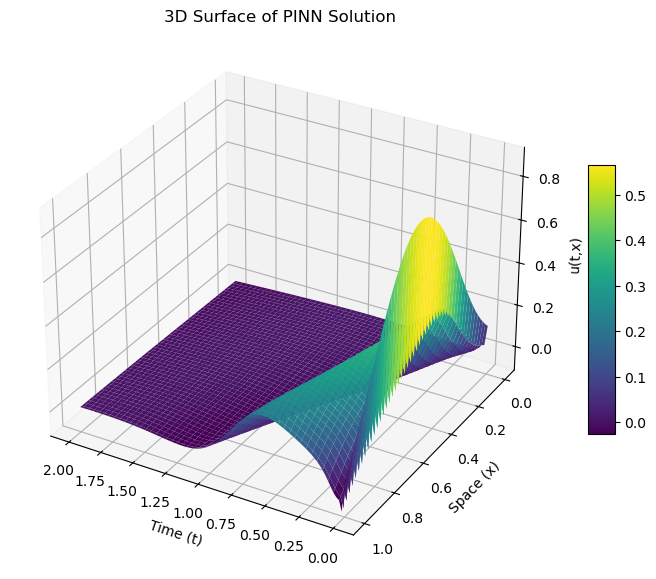

In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Create grid
t_vals = np.linspace(0, T, 100)
x_vals = np.linspace(0, L, 100)

T_grid, X_grid = np.meshgrid(t_vals, x_vals)

# Convert to tensors
t_flat = torch.tensor(T_grid.flatten(), dtype=torch.float32).view(-1,1)
x_flat = torch.tensor(X_grid.flatten(), dtype=torch.float32).view(-1,1)

# Model prediction
with torch.no_grad():
    u_pred = model(t_flat, x_flat)

u_pred = u_pred.numpy().reshape(100, 100)

# ---- 3D Plot ----
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface plot
surf = ax.plot_surface(T_grid, X_grid, u_pred, cmap='viridis')

# Labels
ax.set_xlabel('Time (t)')
ax.set_ylabel('Space (x)')
ax.set_zlabel('u(t,x)')
ax.set_title('3D Surface of PINN Solution')

# View angle (important for clarity)
ax.view_init(elev=30, azim=120)

# Color bar
fig.colorbar(surf, shrink=0.5, aspect=10)

plt.show()

# 1 D Wave Eqn

In [ ]:
import torch
import torch.nn as nn
import numpy as np

# 1. Define the Neural Network
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
       
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, t, x):
        inputs = torch.cat([t, x], dim=1)
        return self.net(inputs)

# 2. Setup the Problem Parameters
c = 1.0        # Wave speed
L = 1.0        # Length of the domain
T = 2.0        # Total time
dx = 0.05      
dt = 0.05      

# 3. Generate Training Data (Collocation points)
N_points = 2000
t_collocation = torch.rand(N_points, 1, requires_grad=False) * T
x_collocation = torch.rand(N_points, 1, requires_grad=False) * L

# 4. Initialize Model and Optimizer
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 5. Training Loop
epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()

    # --- A. Boundary Condition Loss (x = 0 and x = L) ---
    t_bc = torch.rand(500, 1) * T
    x_bc_left = torch.zeros(500, 1)
    x_bc_right = torch.ones(500, 1) * L
    
    u_bc_left_pred = model(t_bc, x_bc_left)
    u_bc_right_pred = model(t_bc, x_bc_right)
    
    loss_bc = torch.mean((u_bc_left_pred - 0)**2) + torch.mean((u_bc_right_pred - 0)**2)

    # --- B. Initial Condition Loss (t = 0) ---
    x_ic = torch.rand(500, 1) * L
    t_ic = torch.zeros(500, 1)
    
    # --- B. Initial Condition Loss (t = 0) ---
    x_ic = torch.rand(500, 1) * L
    t_ic = torch.zeros(500, 1)

    # Initial condition: u(0,x) = 0
    u_ic_exact = torch.zeros_like(x_ic)
    u_ic_pred = model(t_ic, x_ic)

    loss_ic = torch.mean((u_ic_pred - u_ic_exact)**2)

    # --- C. PDE Loss using Finite Difference Method ---
    # We need u(t, x), u(t+dt, x), and u(t, x-dx)
    u_tx = model(t_collocation, x_collocation)
    
    # Forward difference in time
    u_t_plus_dt = model(t_collocation + dt, x_collocation)
    dt_approx = (u_t_plus_dt - u_tx) / dt
    
    # Backward difference in space
    u_x_minus_dx = model(t_collocation, x_collocation - dx)
    dx_approx = (u_tx - u_x_minus_dx) / dx
    
    # PDE Residual: u_t + c * u_x = 0
    pde_residual = dt_approx + c * dx_approx
    loss_pde = torch.mean(pde_residual**2)

    # --- D. Total Loss and Backpropagation ---
    total_loss = loss_ic + loss_bc + loss_pde
    total_loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f'Epoch {epoch}, Loss: {total_loss.item():.6f}')

Epoch 0, Loss: 0.073862


Epoch 500, Loss: 0.000002
Epoch 1000, Loss: 0.000001
Epoch 1500, Loss: 0.000001
Epoch 2000, Loss: 0.000001
Epoch 2500, Loss: 0.000000
Epoch 3000, Loss: 0.000000
Epoch 3500, Loss: 0.000000
Epoch 4000, Loss: 0.000000
Epoch 4500, Loss: 0.000002


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Create grid
t_vals = np.linspace(0, T, 100)
x_vals = np.linspace(0, L, 100)

T_grid, X_grid = np.meshgrid(t_vals, x_vals)

t_flat = torch.tensor(T_grid.flatten(), dtype=torch.float32).view(-1,1)
x_flat = torch.tensor(X_grid.flatten(), dtype=torch.float32).view(-1,1)


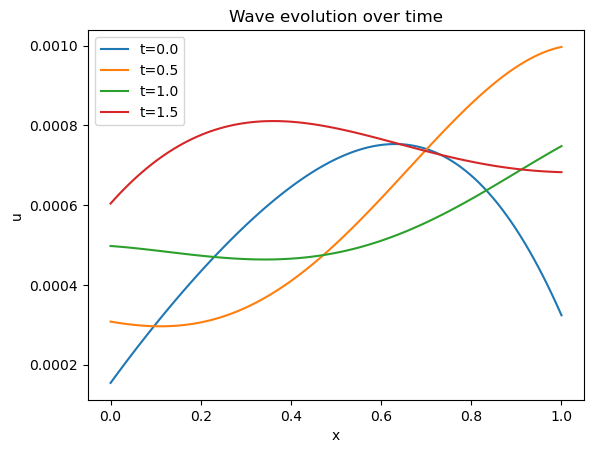

In [12]:
x_vals = np.linspace(0, L, 100)
x_tensor = torch.tensor(x_vals, dtype=torch.float32).view(-1,1)

times = [0.0, 0.5, 1.0, 1.5]

plt.figure()

for t_val in times:
    t_tensor = torch.full_like(x_tensor, t_val)
    
    with torch.no_grad():
        u_pred = model(t_tensor, x_tensor).numpy()
    
    plt.plot(x_vals, u_pred, label=f't={t_val}')

plt.legend()
plt.xlabel('x')
plt.ylabel('u')
plt.title('Wave evolution over time')
plt.show()

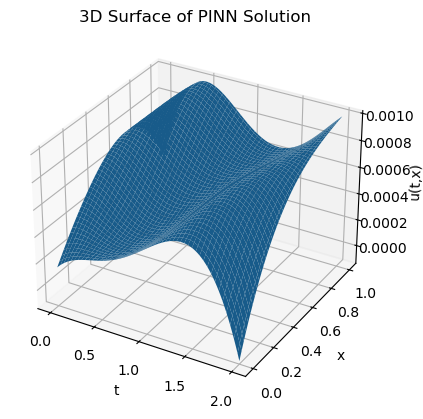

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create grid
t_vals = np.linspace(0, T, 100)
x_vals = np.linspace(0, L, 100)

T_grid, X_grid = np.meshgrid(t_vals, x_vals)

# Convert to tensors
t_flat = torch.tensor(T_grid.flatten(), dtype=torch.float32).view(-1,1)
x_flat = torch.tensor(X_grid.flatten(), dtype=torch.float32).view(-1,1)

# Get predictions
with torch.no_grad():
    u_pred = model(t_flat, x_flat)

u_pred = u_pred.numpy().reshape(100, 100)

# Plot 3D surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(T_grid, X_grid, u_pred)

ax.set_xlabel('t')
ax.set_ylabel('x')
ax.set_zlabel('u(t,x)')
ax.set_title('3D Surface of PINN Solution')

plt.show()

# Laplace Eqn

In [ ]:
import torch
import torch.nn as nn
import numpy as np


# 1. Neural Network

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        return self.net(inputs)


# 2. Parameters
L = 1.0
dx = 0.02

model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# 3. Collocation Points
N = 2000
x_col = torch.rand(N,1) * L
y_col = torch.rand(N,1) * L


# 4. Training
epochs = 5000

for epoch in range(epochs):
    optimizer.zero_grad()


    # A. Boundary Conditions

    # Left (x=0): T=0
    y_bc = torch.rand(500,1)
    x_left = torch.zeros_like(y_bc)
    T_left = model(x_left, y_bc)

    # Right (x=1): T=0
    x_right = torch.ones_like(y_bc)
    T_right = model(x_right, y_bc)

    # Bottom (y=0): T=0
    x_bc = torch.rand(500,1)
    y_bottom = torch.zeros_like(x_bc)
    T_bottom = model(x_bc, y_bottom)

    # Top (y=1): T=100
    y_top = torch.ones_like(x_bc)
    T_top = model(x_bc, y_top)

    loss_bc = (
        torch.mean(T_left**2) +
        torch.mean(T_right**2) +
        torch.mean(T_bottom**2) +
        torch.mean((T_top - 100)**2)
    )

 
    # B. PDE (Finite Difference)
     
    T = model(x_col, y_col)

    # second derivative wrt x
    T_x_plus = model(x_col + dx, y_col)
    T_x_minus = model(x_col - dx, y_col)
    d2T_dx2 = (T_x_plus - 2*T + T_x_minus) / dx**2

    # second derivative wrt y
    T_y_plus = model(x_col, y_col + dx)
    T_y_minus = model(x_col, y_col - dx)
    d2T_dy2 = (T_y_plus - 2*T + T_y_minus) / dx**2

    # Laplace residual
    residual = d2T_dx2 + d2T_dy2
    loss_pde = torch.mean(residual**2)

      
    # Total Loss
    loss = loss_bc + loss_pde
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 9984.664062
Epoch 500, Loss: 7079.088379
Epoch 1000, Loss: 4801.628418
Epoch 1500, Loss: 3305.863525
Epoch 2000, Loss: 2278.900879
Epoch 2500, Loss: 1570.645142
Epoch 3000, Loss: 1025.411743
Epoch 3500, Loss: 689.007446
Epoch 4000, Loss: 557.868774
Epoch 4500, Loss: 431.974731


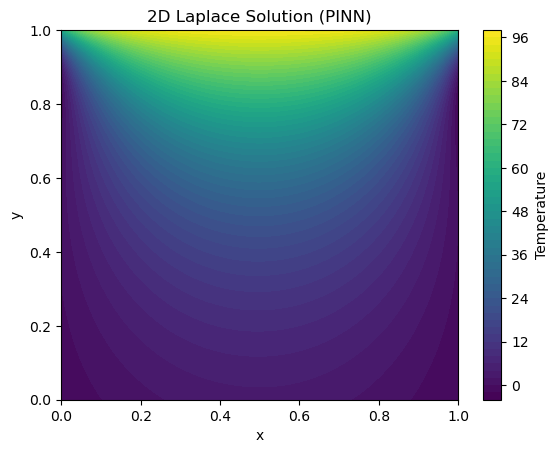

In [17]:
import matplotlib.pyplot as plt

x = np.linspace(0,1,100)
y = np.linspace(0,1,100)
X, Y = np.meshgrid(x,y)

x_t = torch.tensor(X.flatten(), dtype=torch.float32).view(-1,1)
y_t = torch.tensor(Y.flatten(), dtype=torch.float32).view(-1,1)

with torch.no_grad():
    T_pred = model(x_t, y_t).numpy().reshape(100,100)

plt.contourf(X, Y, T_pred, levels=50)
plt.colorbar(label="Temperature")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Laplace Solution (PINN)")
plt.show()

# Triangulr Boundary Condition

- A triangle with vertices: (0,0)
(1,0)
(0,1)
-  Boundary	Condition
- Base (y = 0)	𝑇=0
- Left (x = 0)	𝑇=25
- Hypotenuse (x + y = 1)  𝑇=100

In [18]:
import torch
import torch.nn as nn
import numpy as np

# 1. Neural Network
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        return self.net(inputs)

# 2. Parameters
L = 1.0
dx = 0.02

model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 3. Collocation Points
N = 2000
x_col = torch.rand(N,1)
y_col = torch.rand(N,1)

mask = (x_col + y_col <= 1)
x_col = x_col[mask].view(-1,1)
y_col = y_col[mask].view(-1,1)

# 4. Training
epochs = 20000

for epoch in range(epochs):
    optimizer.zero_grad()

    # A. Boundary Conditions

    x_base = torch.rand(500,1)
    y_base = torch.zeros_like(x_base)
    T_base = model(x_base, y_base)

    y_left = torch.rand(500,1)
    x_left = torch.zeros_like(y_left)
    T_left = model(x_left, y_left)

    x_h = torch.rand(500,1)
    y_h = 1 - x_h
    T_h = model(x_h, y_h)

    loss_bc = (
    torch.mean(T_base**2) +                 # T=0
    torch.mean((T_left - 25)**2) +          # T=25
    torch.mean((T_h - 100)**2)              # T=100
)

    # B. PDE (Finite Difference)

    T = model(x_col, y_col)

    # second derivative wrt x
    T_x_plus = model(x_col + dx, y_col)
    T_x_minus = model(x_col - dx, y_col)
    d2T_dx2 = (T_x_plus - 2*T + T_x_minus) / dx**2

    # second derivative wrt y
    T_y_plus = model(x_col, y_col + dx)
    T_y_minus = model(x_col, y_col - dx)
    d2T_dy2 = (T_y_plus - 2*T + T_y_minus) / dx**2

    # Laplace residual
    residual = d2T_dx2 + d2T_dy2
    loss_pde = torch.mean(residual**2)

    # Total Loss
    loss = loss_bc + loss_pde
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 10680.227539
Epoch 500, Loss: 6910.459473
Epoch 1000, Loss: 5798.672852
Epoch 1500, Loss: 5470.892578
Epoch 2000, Loss: 3324.364258
Epoch 2500, Loss: 2452.625244
Epoch 3000, Loss: 2004.537720
Epoch 3500, Loss: 1758.183105
Epoch 4000, Loss: 1577.525269
Epoch 4500, Loss: 1388.362427
Epoch 5000, Loss: 1184.584229
Epoch 5500, Loss: 1038.180420
Epoch 6000, Loss: 863.786316
Epoch 6500, Loss: 798.115051
Epoch 7000, Loss: 692.897888
Epoch 7500, Loss: 633.314087
Epoch 8000, Loss: 594.619629
Epoch 8500, Loss: 561.975159
Epoch 9000, Loss: 484.206390
Epoch 9500, Loss: 455.040802
Epoch 10000, Loss: 477.860596
Epoch 10500, Loss: 468.951111
Epoch 11000, Loss: 417.638855
Epoch 11500, Loss: 446.483185
Epoch 12000, Loss: 472.606903
Epoch 12500, Loss: 459.670227
Epoch 13000, Loss: 518.750305
Epoch 13500, Loss: 407.826660
Epoch 14000, Loss: 399.440582
Epoch 14500, Loss: 378.696716
Epoch 15000, Loss: 467.452637
Epoch 15500, Loss: 446.718811
Epoch 16000, Loss: 393.761078
Epoch 16500, Loss: 35

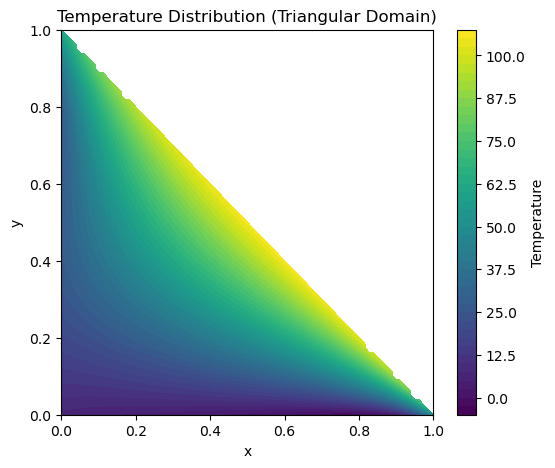

In [19]:
import matplotlib.pyplot as plt

x = np.linspace(0,1,100)
y = np.linspace(0,1,100)
X, Y = np.meshgrid(x,y)

x_t = torch.tensor(X.flatten(), dtype=torch.float32).view(-1,1)
y_t = torch.tensor(Y.flatten(), dtype=torch.float32).view(-1,1)

with torch.no_grad():
    T_pred = model(x_t, y_t).numpy().reshape(100,100)

# Mask outside triangle
mask = (X + Y <= 1)
T_pred[~mask] = np.nan

plt.figure(figsize=(6,5))
plt.contourf(X, Y, T_pred, levels=50)
plt.colorbar(label="Temperature")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Temperature Distribution (Triangular Domain)")
plt.show()

# Traning with GPU and 50000 Iterations

In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


# 0. Device (GPU / CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# 1. Neural Network
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        return self.net(inputs)

model = PINN().to(device)


# 2. Parameters
dx = 0.02
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# 3. Collocation Points (Triangle)
N = 5000

x_col = torch.rand(N,1, device=device)
y_col = torch.rand(N,1, device=device)

mask = (x_col + y_col <= 1)
x_col = x_col[mask].view(-1,1)
y_col = y_col[mask].view(-1,1)


# 4. Training

epochs = 50000

for epoch in range(epochs):
    optimizer.zero_grad()

    # A. Boundary Conditions

    # Base: y = 0 → T = 0
    x_base = torch.rand(500,1, device=device)
    y_base = torch.zeros_like(x_base)
    T_base = model(x_base, y_base)

    # Left: x = 0 → T = 25
    y_left = torch.rand(1000,1, device=device)
    x_left = torch.zeros_like(y_left)
    T_left = model(x_left, y_left)

    # Hypotenuse: x + y = 1 → T = 100
    x_h = torch.rand(500,1, device=device)
    y_h = 1 - x_h
    T_h = model(x_h, y_h)

    loss_bc = (
        torch.mean(T_base**2) +
        torch.mean((T_left - 25)**2) +
        torch.mean((T_h - 100)**2)
    )

    # B. PDE (Laplace Equation)
    T = model(x_col, y_col)

    T_x_plus = model(x_col + dx, y_col)
    T_x_minus = model(x_col - dx, y_col)
    d2T_dx2 = (T_x_plus - 2*T + T_x_minus) / dx**2

    T_y_plus = model(x_col, y_col + dx)
    T_y_minus = model(x_col, y_col - dx)
    d2T_dy2 = (T_y_plus - 2*T + T_y_minus) / dx**2

    residual = d2T_dx2 + d2T_dy2
    loss_pde = torch.mean(residual**2)

    # Total Loss
    loss = 10*loss_bc + loss_pde   # weighted BC (important)
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")




Using device: cuda
Epoch 0, Loss: 105867.250000
Epoch 500, Loss: 69841.210938
Epoch 1000, Loss: 58308.171875
Epoch 1500, Loss: 39224.562500
Epoch 2000, Loss: 27793.781250
Epoch 2500, Loss: 21169.169922
Epoch 3000, Loss: 17597.363281
Epoch 3500, Loss: 14955.734375
Epoch 4000, Loss: 11855.675781
Epoch 4500, Loss: 8245.950195
Epoch 5000, Loss: 5937.418457
Epoch 5500, Loss: 4677.152344
Epoch 6000, Loss: 4532.735352
Epoch 6500, Loss: 3867.852539
Epoch 7000, Loss: 3898.437012
Epoch 7500, Loss: 3112.442383
Epoch 8000, Loss: 2949.382568
Epoch 8500, Loss: 3459.022217
Epoch 9000, Loss: 2976.445801
Epoch 9500, Loss: 2992.665039
Epoch 10000, Loss: 2878.033447
Epoch 10500, Loss: 3120.342773
Epoch 11000, Loss: 2868.607666
Epoch 11500, Loss: 3225.266113
Epoch 12000, Loss: 2764.016846
Epoch 12500, Loss: 2494.698730
Epoch 13000, Loss: 2514.738525
Epoch 13500, Loss: 2416.421143
Epoch 14000, Loss: 2445.851807
Epoch 14500, Loss: 2484.568848
Epoch 15000, Loss: 2141.000977
Epoch 15500, Loss: 2503.755371
Epo

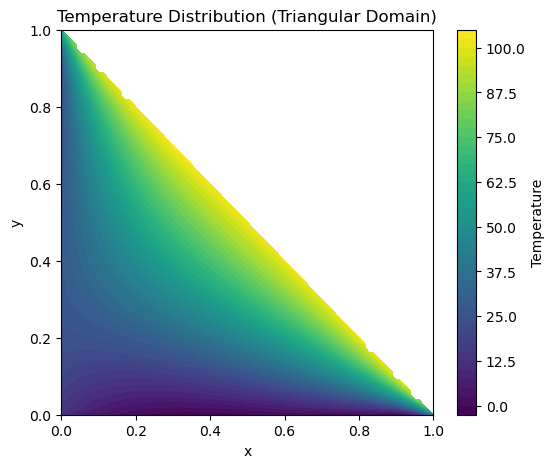

tensor(367.2958, device='cuda:0', grad_fn=<AddBackward0>)


In [11]:
# 5. Visualization

x = np.linspace(0,1,100)
y = np.linspace(0,1,100)
X, Y = np.meshgrid(x,y)

x_t = torch.tensor(X.flatten(), dtype=torch.float32).view(-1,1).to(device)
y_t = torch.tensor(Y.flatten(), dtype=torch.float32).view(-1,1).to(device)

with torch.no_grad():
    T_pred = model(x_t, y_t).cpu().numpy().reshape(100,100)

# Mask outside triangle
mask = (X + Y <= 1)
T_pred[~mask] = np.nan

plt.figure(figsize=(6,5))
plt.contourf(X, Y, T_pred, levels=50)
plt.colorbar(label="Temperature")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Temperature Distribution (Triangular Domain)")
plt.show()
print(loss_bc + loss_pde)

In [20]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


# 0. Device (GPU / CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# 1. Neural Network
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        return self.net(inputs)

model = PINN().to(device)


# 2. Parameters
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5000,   # reduce every 5000 epochs
    gamma=0.5         # halve the learning rate
)
dx = 0.02



# 3. Collocation Points (Triangle)
N = 5000

x_col = torch.rand(N,1, device=device)
y_col = torch.rand(N,1, device=device)

mask = (x_col + y_col <= 1)
x_col = x_col[mask].view(-1,1)
y_col = y_col[mask].view(-1,1)


# 4. Training

epochs = 50000

for epoch in range(epochs):
    optimizer.zero_grad()

    # A. Boundary Conditions

    # Base: y = 0 → T = 0
    x_base = torch.rand(500,1, device=device)
    y_base = torch.zeros_like(x_base)
    T_base = model(x_base, y_base)

    # Left: x = 0 → T = 25
    y_left = torch.rand(1000,1, device=device)
    x_left = torch.zeros_like(y_left)
    T_left = model(x_left, y_left)

    # Hypotenuse: x + y = 1 → T = 100
    x_h = torch.rand(500,1, device=device)
    y_h = 1 - x_h
    T_h = model(x_h, y_h)

    loss_bc = (
        torch.mean(T_base**2) +
        torch.mean((T_left - 25)**2) +
        torch.mean((T_h - 100)**2)
    )

    # B. PDE (Laplace Equation)
    T = model(x_col, y_col)

    T_x_plus = model(x_col + dx, y_col)
    T_x_minus = model(x_col - dx, y_col)
    d2T_dx2 = (T_x_plus - 2*T + T_x_minus) / dx**2

    T_y_plus = model(x_col, y_col + dx)
    T_y_minus = model(x_col, y_col - dx)
    d2T_dy2 = (T_y_plus - 2*T + T_y_minus) / dx**2

    residual = d2T_dx2 + d2T_dy2
    loss_pde = torch.mean(residual**2)

    # Total Loss
    loss = 20*loss_bc + loss_pde   # weighted BC (important)
    loss.backward()
    optimizer.step()

    scheduler.step()


    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")




Using device: cuda
Epoch 0, Loss: 212486.843750
Epoch 500, Loss: 139915.609375
Epoch 1000, Loss: 116719.625000
Epoch 1500, Loss: 109767.812500
Epoch 2000, Loss: 67173.250000
Epoch 2500, Loss: 46294.414062
Epoch 3000, Loss: 34483.785156
Epoch 3500, Loss: 21839.273438
Epoch 4000, Loss: 14058.088867
Epoch 4500, Loss: 9476.915039
Epoch 5000, Loss: 7755.685059
Epoch 5500, Loss: 7062.607910
Epoch 6000, Loss: 6807.638184
Epoch 6500, Loss: 4948.593750
Epoch 7000, Loss: 4834.315430
Epoch 7500, Loss: 4734.604980
Epoch 8000, Loss: 4087.892578
Epoch 8500, Loss: 4687.121094
Epoch 9000, Loss: 4681.513672
Epoch 9500, Loss: 4003.241455
Epoch 10000, Loss: 4356.497070
Epoch 10500, Loss: 3961.553223
Epoch 11000, Loss: 4208.151367
Epoch 11500, Loss: 3621.527832
Epoch 12000, Loss: 3974.755859
Epoch 12500, Loss: 3460.334473
Epoch 13000, Loss: 3034.104248
Epoch 13500, Loss: 3066.344727
Epoch 14000, Loss: 3107.942139
Epoch 14500, Loss: 3458.904053
Epoch 15000, Loss: 3038.256836
Epoch 15500, Loss: 3457.558838


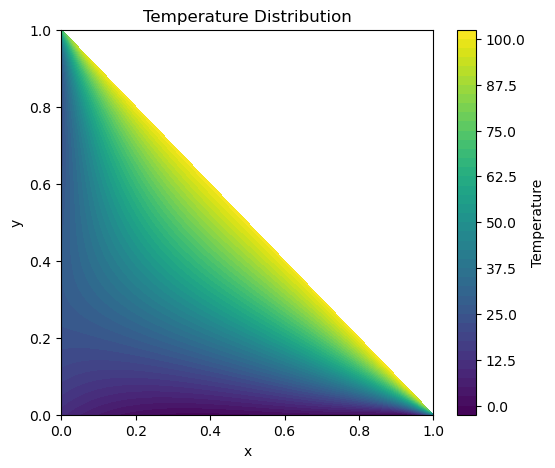

tensor(188.9540, device='cuda:0', grad_fn=<AddBackward0>)


In [22]:
x = np.linspace(0, 1, 200)
y = np.linspace(0, 1, 200)

X, Y = np.meshgrid(x, y)

# 🔥 Move to GPU
x_t = torch.tensor(X.flatten(), dtype=torch.float32).view(-1,1).to(device)
y_t = torch.tensor(Y.flatten(), dtype=torch.float32).view(-1,1).to(device)

# Predict
with torch.no_grad():
    T_pred = model(x_t, y_t).cpu().numpy().reshape(200, 200)

# Mask triangle
mask = (X + Y <= 1)
T_pred[~mask] = np.nan

# Plot
plt.figure(figsize=(6,5))
plt.contourf(X, Y, T_pred, levels=50)
plt.colorbar(label="Temperature")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Temperature Distribution")

plt.show()



print(loss_bc + loss_pde)